In [21]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from geoai.utils_ds.DataFrameOps import DataFrameOperations
from geoai.utils_ds.VisualizeOps import VisualizeOperations
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
df_ops = DataFrameOperations()
vis_ops = VisualizeOperations()

# Load CSV containing S2 Bands
BLUE, GREEN, RED, NIR, SWIR

In [22]:
X_train = pd.read_csv("csv_files/X_train.csv")
X_val = pd.read_csv("csv_files/X_val.csv")
X_test = pd.read_csv("csv_files/X_test.csv")
y_train = pd.read_csv("csv_files/y_train.csv")
y_val = pd.read_csv("csv_files/y_val.csv")
y_test = pd.read_csv("csv_files/y_test.csv")
X_train.head(1)

,BLUE,GREEN,RED,NIR,SWIR
0,1640.5,1671.6,1837.5,1918.3334,2692.8333


In [23]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [24]:
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_scaled)
y_pred_val = lr.predict(X_val_scaled)
y_pred_test = lr.predict(X_test_scaled)

# Types of Accuracy

- Accuracy: Good for balanced classes but can be misleading if classes are imbalanced.
- Precision: Indicates the quality of positive predictions.
- Recall (Sensitivity): Indicates the coverage of actual positive instances.
- F1 Score: Balances precision and recall, making it useful for imbalanced classes.

In [25]:
# calculate the accuracy using f1_score

def calcuate_accuracy(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred, normalize=True)
    precision = precision_score(y_true, y_pred, average="weighted")  
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    print("Accuracy: ", accuracy)
    print("Precision: ", precision)
    print("Recall: ", recall)
    print("F1 Score: ", f1)
    print(classification_report(y_true, y_pred))


print("Validation Set")
calcuate_accuracy(y_val, y_pred_val)
print("Test Set")
calcuate_accuracy(y_test, y_pred_test)

Validation Set
Accuracy:  0.8925619834710744
Precision:  0.8977828975014929
Recall:  0.8925619834710744
F1 Score:  0.8934203483547187
              precision    recall  f1-score   support

           0       0.91      0.83      0.87       259
           1       0.99      0.99      0.99       108
           2       0.77      0.88      0.82       167
           3       1.00      1.00      1.00        71

    accuracy                           0.89       605
   macro avg       0.92      0.93      0.92       605
weighted avg       0.90      0.89      0.89       605

Test Set
Accuracy:  0.8801652892561983
Precision:  0.8836360609087882
Recall:  0.8801652892561983
F1 Score:  0.8810948547927253
              precision    recall  f1-score   support

           0       0.88      0.83      0.86       207
           1       1.00      0.99      0.99        86
           2       0.76      0.84      0.80       134
           3       1.00      1.00      1.00        57

    accuracy                   

# Confusion matrix

- True Positive (TP): The number of instances that were correctly classified.
- False Positive (FP): The number of instances that were incorrectly classified as a given class.
- False Negative (FN): The number of instances that were incorrectly classified as another class.
- True Negative (TN): The number of instances that were correctly not classified as a given class.

Builtup:

- TP: 180 (correctly classified as builtup)
- FP: 2 (incorrectly classified as builtup when they are not)
- FN: 9 (incorrectly classified as not builtup when they are)

Grass:

- TP: 105 (correctly classified as grass)
- FP: 3 (incorrectly classified as grass when they are not)
- FN: 0 (incorrectly classified as not grass when they are)

Road:
- TP: 107 (correctly classified as road)
- FP: 2 (incorrectly classified as road when they are not)
- FN: 0 (incorrectly classified as not road when they are)

Trees:
- TP: 71 (correctly classified as trees)
- FP: 0 (incorrectly classified as trees when they are not)
- FN: 0 (incorrectly classified as not trees when they are)

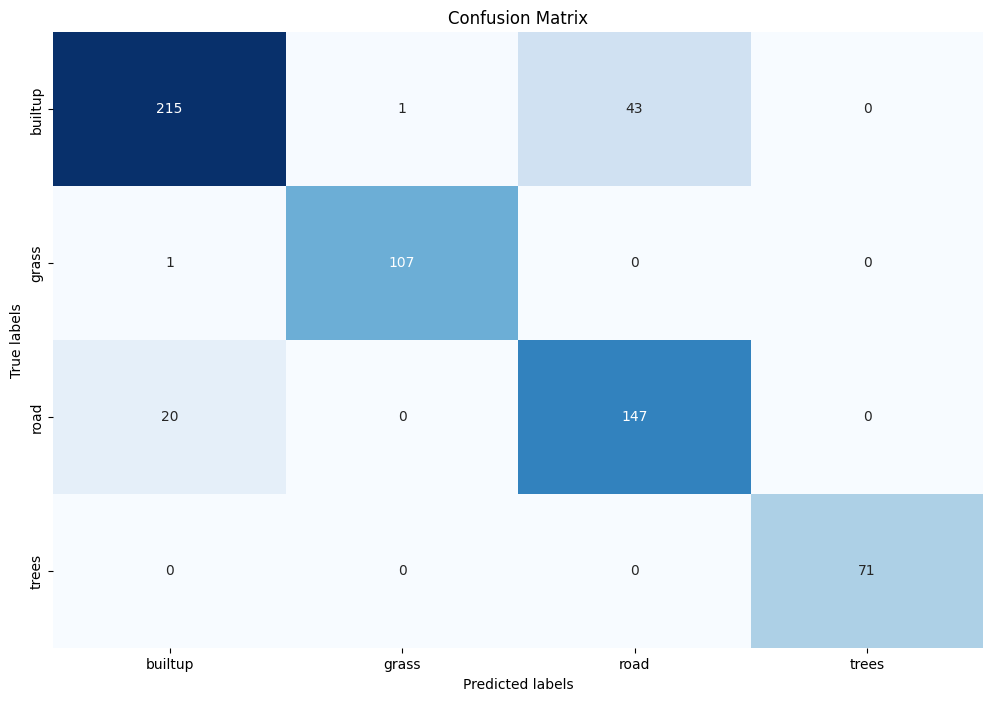

<Figure size 640x480 with 0 Axes>

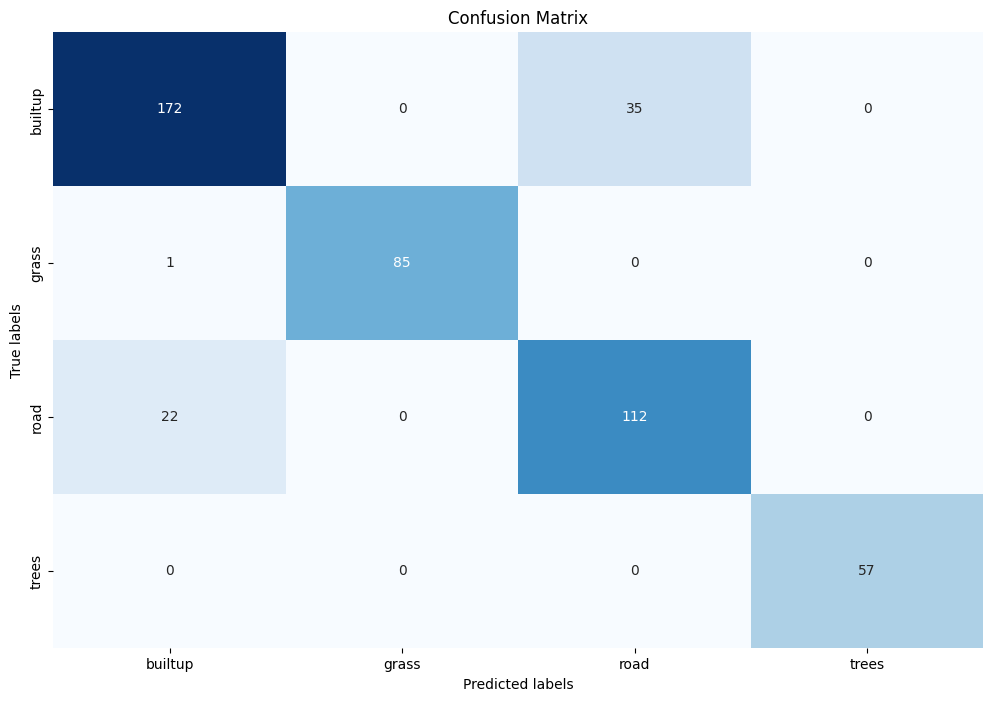

<Figure size 640x480 with 0 Axes>

In [26]:
label_mapping = {0: 'builtup', 1: 'grass', 2: 'road', 3: 'trees'}
class_names_str = [label_mapping[label] for label in lr.classes_]

vis_ops.plot_confusion_matrix(y_val, y_pred_val, class_names_str)
vis_ops.plot_confusion_matrix(y_test, y_pred_test, class_names_str)

END